# <center> Module 4: Predict House Sale Value for Homes in Boston, USA using Regression Models - A Multi-Model Approach</center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

Use the Dataset provided in the Tech Insights Mission to predict house prices.

Project Outcomes:
1. Use visualizations to show patterns and relationships in the dataset
2. Use multiple machine learning techniques and compare the accuracy of the methods
3. Optimize and display the best method for prediction house price and a summary of the most important features in the dataset.



 The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
 prices and the demand for clean air', J. Environ. Economics & Management,
 vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
 ...', Wiley, 1980.   N.B. Various transformations are used in the table on
 pages 244-261 of the latter.

 #### Variables in order:
 - CRIM     per capita crime rate by town
 - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
 - INDUS    proportion of non-retail business acres per town
 - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
 - NOX      nitric oxides concentration (parts per 10 million)
 - RM       average number of rooms per dwelling
 - AGE      proportion of owner-occupied units built prior to 1940
 - DIS      weighted distances to five Boston employment centres
 - RAD      index of accessibility to radial highways
 - TAX      full-value property-tax rate per \\$10,000
 - PTRATIO  pupil-teacher ratio by town
 - B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
 - LSTAT    \% lower status of the population
 - MEDV     Median value of owner-occupied homes in $1000's

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#Load libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle as pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [4]:
# Read King County data to a dataframe and add column names to a list
df = pd.read_csv('../boston.csv')
#print(df.head())
colNames = list(df)
print(colNames)

['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [5]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4.22239,0.0,18.10,1.0,0.770,5.803,89.0,1.9047,24,666.0,20.2,353.04,14.64,16.8
502,3.47428,0.0,18.10,1.0,0.718,8.780,82.9,1.9047,24,666.0,20.2,354.55,5.29,21.9
503,5.66998,0.0,18.10,1.0,0.631,6.683,96.8,1.3567,24,666.0,20.2,375.33,3.73,50.0
504,6.53876,0.0,18.10,1.0,0.631,7.016,97.5,1.2024,24,666.0,20.2,392.05,2.96,50.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  452 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


In [7]:
df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 452 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     452 non-null    float64
 1   ZN       452 non-null    float64
 2   INDUS    452 non-null    float64
 3   CHAS     452 non-null    float64
 4   NOX      452 non-null    float64
 5   RM       452 non-null    float64
 6   AGE      452 non-null    float64
 7   DIS      452 non-null    float64
 8   RAD      452 non-null    int64  
 9   TAX      452 non-null    float64
 10  PTRATIO  452 non-null    float64
 11  B        452 non-null    float64
 12  LSTAT    452 non-null    float64
 13  MEDV     452 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 53.0 KB


# Visualize Variables

<Axes: >

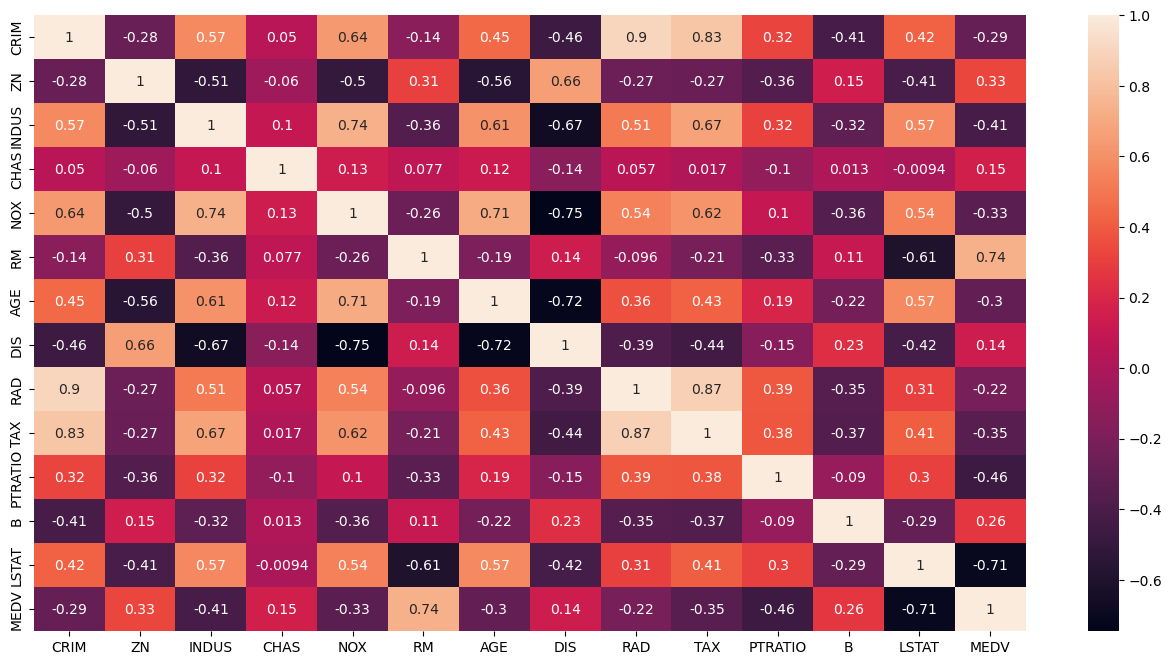

In [9]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(),annot=True)


# House Features


## Living space and location, location, location

<Axes: xlabel='RM', ylabel='DIS'>

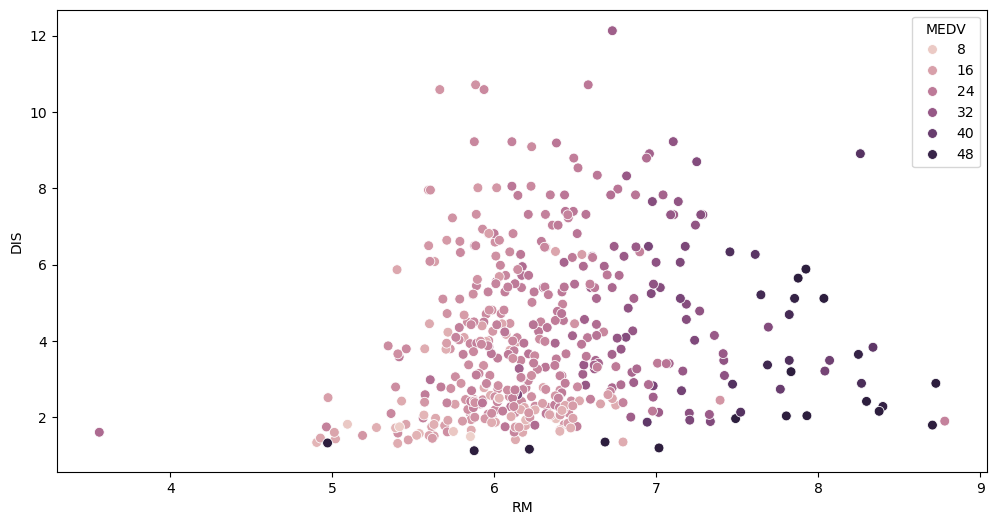

In [10]:
# Price increases with size and proximity to business centre
plt.figure(figsize = (12,6))
sns.scatterplot(x=df['RM'], y = df['DIS'], hue = df["MEDV"], s = 50)

## Create feature and target columns

In [11]:
# Features
x_columns  = len(colNames)-1
X = df.iloc[:,0:x_columns].values

#Target is price, in last column of the dataframe
y = df.iloc[:,x_columns].values

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
#Create training and test sets
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)

# Assign features to a list
colNames = list(df)
model_scores=[]

In [14]:
y_test

array([18.8, 18.9, 24.6, 20.6, 24.4, 15.6, 21.7, 13.8, 23.7, 20. , 19.9,
       22.7, 16.8, 19.1, 13.4, 19.6, 20.4, 21.6, 15. , 32. , 15.2, 50. ,
       27. , 18.7, 25. , 16.7,  6.3, 22. , 17.6, 31.7, 21.7, 19.5, 20.4,
       21. , 24.8, 44. , 29. , 46.7, 18.2, 22.2, 23.8, 23.3, 18.5, 30.1,
       19. , 13.4, 27.5, 15.6, 11.7, 21.7, 24.1, 14.9, 29.9, 22.9, 20.4,
       21.2, 13.4, 19.9, 18.7, 20.1, 13.8, 15.4, 16.1, 24.7, 50. , 18.6,
       21.4, 23. , 50. , 23.9, 22.6, 23.8, 22. , 18.1, 19.6, 14.5, 24.6,
       20.7, 23.5, 14.4, 14.1, 33.2, 24.3, 21.9, 20.3, 37.9, 25. , 48.5,
       43.1, 50. , 19.4])

# Create the Models

## Linear Regression

In [15]:
model = LinearRegression()

In [16]:
model.fit(x_train, y_train)

LinearRegression()

In [17]:
scoreLR = model.score(x_test, y_test)
print(scoreLR)

0.67512886076341


## Polynomial Regression

In [18]:
# for polynomial analysis, we have to transform the data

scoresPR = []
for i in range(1,4):
    poly=PolynomialFeatures(degree=i)
    x_poly = poly.fit_transform(X)
    
    x_trainp, x_testp, y_trainp, y_testp = train_test_split(x_poly, y, test_size=0.2, random_state=0)
    
    model = LinearRegression()
    model.fit(x_trainp, y_trainp)
    
    score = model.score(x_testp, y_testp)
    scoresPR.append(score)
    scorePR = max(scoresPR)

    
bestPoly = scoresPR.index(max(scoresPR)) + 1 # location of max score

print('Max polynomial score is: ',scorePR, "with a value of",bestPoly)

Max polynomial score is:  0.7915262884412232 with a value of 2


## SVR Linear Regression

In [19]:
#3 - Try the SVR linear regression

modelSVR = SVR(kernel='linear').fit(x_train, y_train)
y_pred = modelSVR.predict(x_test)

print(mean_squared_error(y_test, y_pred))

scoreSVR = modelSVR.score(x_test, y_test)
print('Linear SVR Model gives a score of: ',scoreSVR)


30.428294488774938
Linear SVR Model gives a score of:  0.6344325531264372


## SVR Polynomial Regression

In [20]:
deg = list(range(1,11))
scoresSVRpoly = []

for i in deg:
    modelSVRpoly = SVR(kernel='poly',degree=i, gamma='auto', tol = 0.001, max_iter = 100000).fit(x_train, y_train)

    score = modelSVRpoly.score(x_test, y_test)
    scoresSVRpoly.append(score)
    print(i, 'gives a score of: ',score) 

scoreSVRpoly = max(scoresSVRpoly)
bestSVRPoly = scoresSVRpoly.index(max(scoresSVRpoly)) + 1 # location of max score

print('SVR Polynomial Regression gives a best score of:', scoreSVRpoly, "with a degree of",bestSVRPoly )  
    

1 gives a score of:  0.6686199916073652
2 gives a score of:  0.5251650916313778
3 gives a score of:  0.48281679665902333
4 gives a score of:  0.541466700388822
5 gives a score of:  0.42346256348306865
6 gives a score of:  0.5491778838540997
7 gives a score of:  0.3192932593294122
8 gives a score of:  0.14662098755029507
9 gives a score of:  -0.16376279833591156
10 gives a score of:  -0.2550052007121715
SVR Polynomial Regression gives a best score of: 0.6686199916073652 with a degree of 1


## KNN Regression

In [21]:
#5 -  Try the KNN regression
tempScore=[]
for i in range(15,25,1):
    modelKNN = KNeighborsRegressor(n_neighbors=i).fit(x_train, y_train)

    score = modelKNN.score(x_test, y_test)
    tempScore.append(score)
    print(i, 'gives a score of: ',score)
scoreKNN = max(tempScore)  

print('KNN Regression gives a score of:', scoreKNN)

15 gives a score of:  0.6848403516423662
16 gives a score of:  0.678843410824602
17 gives a score of:  0.6782384319811094
18 gives a score of:  0.671382029088735
19 gives a score of:  0.667774890303878
20 gives a score of:  0.6604746220437585
21 gives a score of:  0.6558547121099927
22 gives a score of:  0.6549134597714986
23 gives a score of:  0.6544904126168024
24 gives a score of:  0.6501095401686825
KNN Regression gives a score of: 0.6848403516423662


## Decision Tree

In [22]:
# 6 - Do a Decision Tree regressor analysis
modelTree = DecisionTreeRegressor(random_state=0).fit(x_train, y_train)
y_pred = modelTree.predict(x_test) 

scoreDT=modelTree.score(x_test, y_test)
print(scoreDT)

0.7182451384175003


## Random Forest

In [26]:
# 7 - Do a Random Forest Regressor analysis
score=[]
estimator_num=[]
temp_score = []

for estimators in range (1,21,1):
    
    estimator_num.append(estimators)
    modelRandFor = RandomForestRegressor(n_estimators = estimators, 
                                         random_state = 0).fit(x_train,
                                                               y_train)
    y_predRF = modelRandFor.predict(x_test)
    
    score = (modelRandFor.score(x_test, y_test))
    temp_score.append(score)

    print(estimators,'estimators gives a score of:',modelRandFor.score(x_test, y_test))

scoreRF = max(temp_score)
print('Random Forest Maximum Score is:',scoreRF)

1 estimators gives a score of: 0.5998445672439047
2 estimators gives a score of: 0.7858423958917098
3 estimators gives a score of: 0.8423240046404663
4 estimators gives a score of: 0.8279699223268558
5 estimators gives a score of: 0.8383018019672713
6 estimators gives a score of: 0.8471889300219301
7 estimators gives a score of: 0.8533900370909506
8 estimators gives a score of: 0.8602272070168134
9 estimators gives a score of: 0.8520282576745423
10 estimators gives a score of: 0.8565109759585847
11 estimators gives a score of: 0.8498799021026445
12 estimators gives a score of: 0.8431250246877557
13 estimators gives a score of: 0.8507394811846982
14 estimators gives a score of: 0.8443923485819974
15 estimators gives a score of: 0.8466717928216305
16 estimators gives a score of: 0.8486003778576778
17 estimators gives a score of: 0.8495280340691105
18 estimators gives a score of: 0.8423949546014283
19 estimators gives a score of: 0.8407950943471506
20 estimators gives a score of: 0.845710

# Summarize the Results

(Text(0.5, 1.0, 'Randm Forest Prediction'), None)

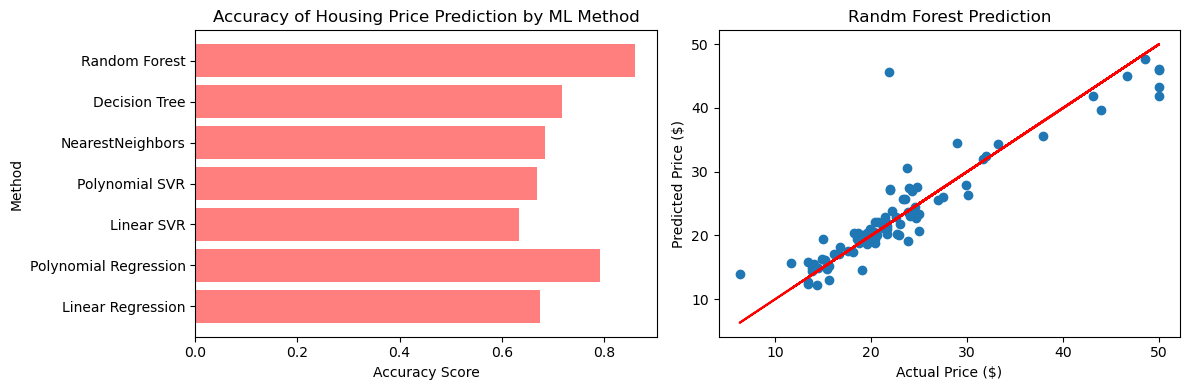

In [27]:
# Store all the model names and scores in lists to plot
model_names = ['Linear Regression','Polynomial Regression',
               'Linear SVR','Polynomial SVR', 'NearestNeighbors', 'Decision Tree',
               'Random Forest']
y_pos = np.arange(len(model_names))
model_scores = [scoreLR,scorePR,scoreSVR,scoreSVRpoly,scoreKNN,scoreDT,scoreRF,]

fig3, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(12,4))
fig3.tight_layout()

# Plot all method scores
ax1.barh(model_names,model_scores, align='center', alpha=0.5,color='red')
ax1.set_yticklabels(model_names), ax1.set_ylabel('Method'), ax1.set_xlabel('Accuracy Score')
ax1.set_title('Accuracy of Housing Price Prediction by ML Method')

# Plot best predicton actual vs predicted prices
ax2.scatter(y_test,y_predRF)
ax2.plot(y_test,y_test,'r') # Add perfect predictions as red line

ax2.set_ylabel('Predicted Price ($)'), ax2.set_xlabel('Actual Price ($)')
ax2.set_title('Randm Forest Prediction'), fig3.tight_layout()

In this example, Random Forest still gives the best prediction with an accuracy score of 86%.  The prediction is quite linear with some variability. The model could potentially be improved with further feature engineering. 

#### Another way of visualizing the error in the predictions is with a Residual Plot:

The residuals are calculated as:

Residual = Actual Value − Predicted Value

A good residuals plot should show randomly scattered points around y = 0, 
indicating that the model captures patterns well.

1. If randomly scattered around 𝑦 = 0, → Model fits well.
2. If a clear pattern (e.g., curved shape) → Model may be missing trends (consider polynomial regression).
3. If heteroscedasticity (residuals spread increases for larger predictions) → Model may not capture variance properly.

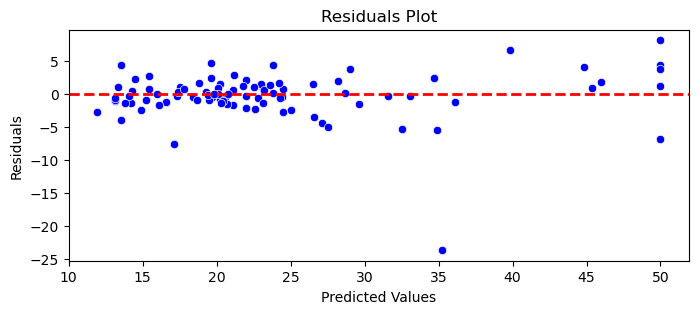

In [28]:
residuals = y_test - y_predRF
plt.figure(figsize=(8, 3))
sns.scatterplot(x=y_pred, y=residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)  # Reference line at y=0

plt.xlabel("Predicted Values"), plt.ylabel("Residuals"), plt.title("Residuals Plot")
plt.show()

## Save the best model - Random Forest

In [29]:
#save the Random Forest model to disk
filename = 'BostonHousePricing.sav'
pickle.dump(modelRandFor, open(filename, 'wb'))

In [30]:
#Load the model at some point in the future
BHP_1 = pickle.load(open('BostonHousePricing.sav','rb'))